In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score,precision_score,recall_score,f1_score, accuracy_score, classification_report, confusion_matrix, RocCurveDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.feature_selection import RFE
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedBaggingClassifier,EasyEnsembleClassifier,RUSBoostClassifier
np.random.seed(42)

# Model 1: Random Forest (with SMOTE):

In [2]:
df = pd.read_csv("ILPD_augmented_gmm (2)og.csv")

In [3]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         1000 non-null   int64  
 1   Gender                      1000 non-null   object 
 2   Total_Bilirubin             1000 non-null   float64
 3   Direct_Bilirubin            1000 non-null   float64
 4   Alkaline_Phosphotase        1000 non-null   int64  
 5   Alamine_Aminotransferase    1000 non-null   int64  
 6   Aspartate_Aminotransferase  1000 non-null   int64  
 7   Total_Proteins              1000 non-null   float64
 8   Albumin                     1000 non-null   float64
 9   Albumin_Globulin_Ratio      1000 non-null   float64
 10  Target                      1000 non-null   int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 86.1+ KB


,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_Globulin_Ratio,Target
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,44.322000,2.334957,1.002874,264.59700,59.84500,78.665000,6.296814,3.022784,0.920334,1.585000
std,16.911662,4.882496,2.222423,194.08695,141.95175,224.227868,1.012734,0.715901,0.272769,0.492969
min,4.000000,0.400000,0.100000,52.00000,5.00000,5.000000,2.700000,0.900000,0.300000,1.000000
25%,32.000000,0.717056,0.200000,175.75000,21.00000,22.000000,5.600000,2.511243,0.741577,1.000000
50%,45.000000,0.957613,0.300000,215.00000,31.00000,34.000000,6.271079,3.000000,0.900000,2.000000
75%,57.000000,1.626594,0.648501,289.00000,50.00000,65.000000,7.000000,3.500000,1.055410,2.000000
max,90.000000,75.000000,19.700000,2110.00000,2000.00000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [4]:
df.isna().sum()

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Proteins,0
Albumin,0
Albumin_Globulin_Ratio,0


In [5]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype == 'str':
        df[col] = le.fit_transform(df[col])

In [6]:
X = df.drop('Target', axis=1)
y = df['Target']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 800
Test set size: 200


In [8]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [9]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(random_state=42)

In [10]:
y_pred_rf = rf.predict(X_test)
print(f"Random Forest Accuracy(with SMOTE): {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy(with SMOTE): 0.8450

Classification Report:
               precision    recall  f1-score   support

           1       0.78      0.86      0.82        81
           2       0.90      0.83      0.86       119

    accuracy                           0.84       200
   macro avg       0.84      0.85      0.84       200
weighted avg       0.85      0.84      0.85       200



In [11]:
rf.fit(X_train, y_train)
y_pred_baseline = rf.predict(X_test)
print(f"Baseline RF (no SMOTE) Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

Baseline RF (no SMOTE) Accuracy: 0.8600

Classification Report:
              precision    recall  f1-score   support

           1       0.81      0.85      0.83        81
           2       0.90      0.87      0.88       119

    accuracy                           0.86       200
   macro avg       0.85      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200



In [13]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_balanced.fit(X_train, y_train)
y_pred_balanced = rf_balanced.predict(X_test)
print(f"RF with class_weight='balanced' Accuracy: {accuracy_score(y_test, y_pred_balanced):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

RF with class_weight='balanced' Accuracy: 0.8250

Classification Report:
              precision    recall  f1-score   support

           1       0.79      0.78      0.78        81
           2       0.85      0.86      0.85       119

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



In [14]:
n_estimators_options = [150, 200, 300]
results = []
for n in n_estimators_options:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
    results.append((n, cv_scores.mean()))
    print(f"n_estimators={n}: CV Accuracy = {cv_scores.mean():.4f}")
best_n = max(results, key=lambda x: x[1])[0]
print(f"\nBest n_estimators: {best_n}")

n_estimators=150: CV Accuracy = 0.8150
n_estimators=200: CV Accuracy = 0.8125
n_estimators=300: CV Accuracy = 0.8137

Best n_estimators: 150


In [15]:
max_depth_options = [None, 5, 10, 20]
results = []
for depth in max_depth_options:
    rf = RandomForestClassifier(
        n_estimators=150,
        max_depth=depth,
        random_state=42
    )
    cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
    results.append((depth, cv_scores.mean()))
    print(f"max_depth={depth}: CV Accuracy = {cv_scores.mean():.4f}")
best_depth = max(results, key=lambda x: x[1])[0]
print(f"\nBest max_depth: {best_depth}")

max_depth=None: CV Accuracy = 0.8150
max_depth=5: CV Accuracy = 0.8113
max_depth=10: CV Accuracy = 0.8088
max_depth=20: CV Accuracy = 0.8150

Best max_depth: None


In [16]:
min_samples_split_options = [2, 5, 10, 20]
results = []
for min_split in min_samples_split_options:
    rf = RandomForestClassifier(
        n_estimators=150,
        max_depth=None,
        min_samples_split=min_split,
        random_state=42
    )
    cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
    results.append((min_split, cv_scores.mean()))
    print(f"min_samples_split={min_split}: CV Accuracy = {cv_scores.mean():.4f}")
best_min_split = max(results, key=lambda x: x[1])[0]
print(f"\nBest min_samples_split: {best_min_split}")

min_samples_split=2: CV Accuracy = 0.8150
min_samples_split=5: CV Accuracy = 0.8150
min_samples_split=10: CV Accuracy = 0.8063
min_samples_split=20: CV Accuracy = 0.8050

Best min_samples_split: 2


In [17]:
min_samples_leaf_options = [1, 2, 4, 8]
results = []
for min_leaf in min_samples_leaf_options:
    rf = RandomForestClassifier(
        n_estimators=150,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=min_leaf,
        random_state=42
    )
    cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
    results.append((min_leaf, cv_scores.mean()))
    print(f"min_samples_leaf={min_leaf}: CV Accuracy = {cv_scores.mean():.4f}")
best_min_leaf = max(results, key=lambda x: x[1])[0]
print(f"\nBest min_samples_leaf: {best_min_leaf}")

min_samples_leaf=1: CV Accuracy = 0.8150
min_samples_leaf=2: CV Accuracy = 0.8125
min_samples_leaf=4: CV Accuracy = 0.8012
min_samples_leaf=8: CV Accuracy = 0.8150

Best min_samples_leaf: 1


In [18]:
n_features = X_train.shape[1]
print(f"Total features: {n_features}")
max_features_options = ['sqrt', 'log2', 0.3, 0.5]
results = []
for max_feat in max_features_options:
    rf = RandomForestClassifier(
        n_estimators=150,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=max_feat,
        random_state=42
    )
    cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
    results.append((max_feat, cv_scores.mean()))
    print(f"max_features={max_feat}: CV Accuracy = {cv_scores.mean():.4f}")
best_max_feat = max(results, key=lambda x: x[1])[0]
print(f"\nBest max_features: {best_max_feat}")

Total features: 10
max_features=sqrt: CV Accuracy = 0.8150
max_features=log2: CV Accuracy = 0.8150
max_features=0.3: CV Accuracy = 0.8150
max_features=0.5: CV Accuracy = 0.8162

Best max_features: 0.5


In [45]:
rf_optimized = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=0.5,
    random_state=42
)
rf_optimized.fit(X_train, y_train)

RandomForestClassifier(max_features=0.5, n_estimators=150, random_state=42)

In [46]:
y_pred_optimized = rf_optimized.predict(X_test)
print(f"Optimized Random Forest Accuracy: {accuracy_score(y_test, y_pred_optimized):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimized))

Optimized Random Forest Accuracy: 0.7600

Classification Report:
              precision    recall  f1-score   support

           1       0.80      0.54      0.65        81
           2       0.74      0.91      0.82       119

    accuracy                           0.76       200
   macro avg       0.77      0.73      0.73       200
weighted avg       0.77      0.76      0.75       200



CONFUSION MATRIX:
              Predicted
              Class 1   Class 2
Actual Class 1       44       37
Actual Class 2       11      108


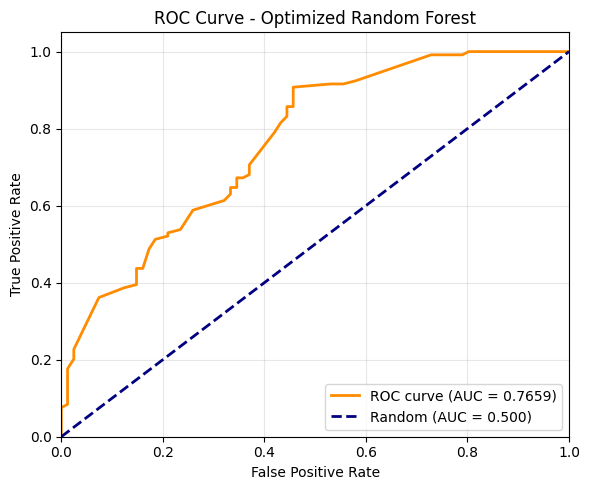

CROSS-VALIDATION RESULTS:
5-Fold CV Accuracy: 0.7190
Fold scores: [0.735 0.705 0.675 0.765 0.715]
Test Accuracy: 0.7600
Gap (CV - Test): 0.0410


In [47]:
cm_rf = confusion_matrix(y_test, y_pred_optimized)
print("CONFUSION MATRIX:")
print("              Predicted")
print("              Class 1   Class 2")
print(f"Actual Class 1   {cm_rf[0,0]:6d}   {cm_rf[0,1]:6d}")
print(f"Actual Class 2   {cm_rf[1,0]:6d}   {cm_rf[1,1]:6d}")

y_proba_rf = rf_optimized.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf, pos_label=2)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Optimized Random Forest')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_rf = cross_val_score(rf_optimized, X, y, cv=cv, scoring='accuracy')

print("CROSS-VALIDATION RESULTS:")
print(f"5-Fold CV Accuracy: {cv_scores_rf.mean():.4f}")
print(f"Fold scores: {cv_scores_rf}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_optimized):.4f}")
print(f"Gap (CV - Test): {abs(cv_scores_rf.mean() - accuracy_score(y_test, y_pred_optimized)):.4f}")

In [21]:
print(f"Original training size: {len(X_train)}")
print(f"SMOTE training size: {len(X_train_balanced)}")
print(f"Class distribution after SMOTE:\n{pd.Series(y_train_balanced).value_counts()}")
rf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)
rf_smote.fit(X_train_balanced, y_train_balanced)
y_pred_smote = rf_smote.predict(X_test)
print(f"Optimized Random Forest(with SMOTE) Accuracy: {accuracy_score(y_test, y_pred_smote):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

Original training size: 800
SMOTE training size: 932
Class distribution after SMOTE:
Target
1    466
2    466
Name: count, dtype: int64
Optimized Random Forest(with SMOTE) Accuracy: 0.8300

Classification Report:
              precision    recall  f1-score   support

           1       0.76      0.85      0.80        81
           2       0.89      0.82      0.85       119

    accuracy                           0.83       200
   macro avg       0.82      0.83      0.83       200
weighted avg       0.84      0.83      0.83       200



In [23]:
rf_balanced_subsample = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=0.5,
    class_weight='balanced_subsample',
    random_state=42
)
rf_balanced_subsample.fit(X_train, y_train)
y_pred_balanced = rf_balanced_subsample.predict(X_test)
print(f"RF with class_weight='balanced_subsample' Accuracy: {accuracy_score(y_test, y_pred_balanced):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

RF with class_weight='balanced_subsample' Accuracy: 0.8700

Classification Report:
              precision    recall  f1-score   support

           1       0.85      0.83      0.84        81
           2       0.88      0.90      0.89       119

    accuracy                           0.87       200
   macro avg       0.87      0.86      0.86       200
weighted avg       0.87      0.87      0.87       200



# Model 2: Optimized Logistic Regression

In [25]:
df = pd.read_csv("ILPD_augmented_gmm (2)og.csv")

In [26]:
# Age
bins = [0, 35, 65, float('inf')]
labels = ['Young Adult', 'Middle-Aged Adult', 'Elderly']
df['Age'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Total Bilirubin
bins = [0, 1.2, float('inf')]
labels = ['normal', 'high']
df['Total_Bilirubin'] = pd.cut(df['Total_Bilirubin'], bins=bins, labels=labels, right=False)

# Direct Bilirubin
bins = [0, 0.3, float('inf')]
labels = ['normal', 'high']
df['Direct_Bilirubin'] = pd.cut(df['Direct_Bilirubin'], bins=bins, labels=labels, right=False)

# Albumin
bins = [0, 3.4, 5.4, float('inf')]
labels = ['low', 'normal', 'high']
df['Albumin'] = pd.cut(df['Albumin'], bins=bins, labels=labels, right=False)

# Alkaline Phosphotase (ALP)
bins = [0, 44, 147, float('inf')]
labels = ['low', 'normal', 'high']
df['Alkaline_Phosphotase'] = pd.cut(df['Alkaline_Phosphotase'], bins=bins, labels=labels, right=False)

# Aspartate Aminotransferase (AST)
bins = [0, 8, 40, float('inf')]
labels = ['low', 'normal', 'high']
df['Aspartate_Aminotransferase'] = pd.cut(df['Aspartate_Aminotransferase'], bins=bins, labels=labels, right=False)

# Total Proteins
bins = [0, 6.0, 8.3, float('inf')]
labels = ['low', 'normal', 'high']
df['Total_Proteins'] = pd.cut(df['Total_Proteins'], bins=bins, labels=labels, right=False)

# Alamine Aminotransferase (ALT)
bins = [0, 40, 120, 400, float('inf')]
labels = ['normal', 'mild', 'moderate', 'severe']
df['Alamine_Aminotransferase'] = pd.cut(df['Alamine_Aminotransferase'], bins=bins, labels=labels, right=False)

# Albumin Globulin Ratio
bins = [0, 1.0, 2.5, float('inf')]
labels = ['low', 'normal', 'high']
df['Albumin_Globulin_Ratio'] = pd.cut(df['Albumin_Globulin_Ratio'], bins=bins, labels=labels, right=False)

In [27]:
columns = df[['Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase',
              'Aspartate_Aminotransferase', 'Alamine_Aminotransferase',
              'Albumin', 'Albumin_Globulin_Ratio', 'Target']]
df = pd.get_dummies(columns, drop_first=True)

In [28]:
X = df.drop('Target', axis=1)
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [30]:
y_pred = lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(class_report)

Accuracy: 0.72
Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.48      0.59        81
           2       0.72      0.89      0.79       119

    accuracy                           0.72       200
   macro avg       0.73      0.69      0.69       200
weighted avg       0.73      0.72      0.71       200



CONFUSION MATRIX:
              Predicted
              Class 1   Class 2
Actual Class 1       47       34
Actual Class 2       23       96


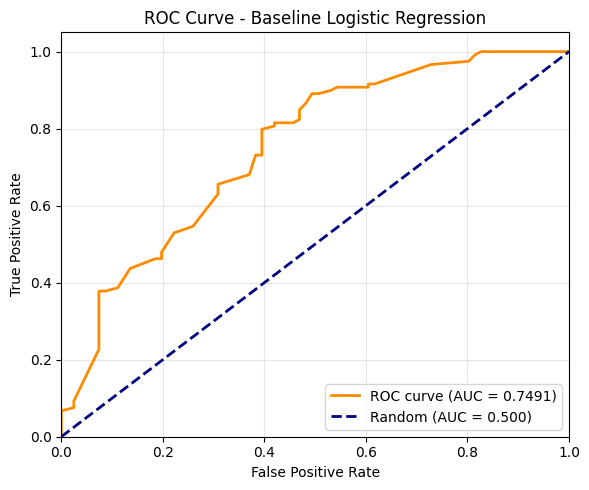

CROSS-VALIDATION RESULTS:
5-Fold CV Accuracy: 0.6830
Fold scores: [0.73  0.68  0.66  0.695 0.65 ]
Test Accuracy: 0.7150
Gap (CV - Test): 0.0320


In [43]:
cm_lr = confusion_matrix(y_test, y_pred)
print("CONFUSION MATRIX:")
print("              Predicted")
print("              Class 1   Class 2")
print(f"Actual Class 1   {cm_lr[0,0]:6d}   {cm_lr[0,1]:6d}")
print(f"Actual Class 2   {cm_lr[1,0]:6d}   {cm_lr[1,1]:6d}")

y_proba_lr = lr.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr, pos_label=2)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_lr:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Baseline Logistic Regression')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lr = cross_val_score(lr, X, y, cv=cv, scoring='accuracy')

print("CROSS-VALIDATION RESULTS:")
print(f"5-Fold CV Accuracy: {cv_scores_lr.mean():.4f}")
print(f"Fold scores: {cv_scores_lr}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Gap (CV - Test): {abs(cv_scores_lr.mean() - accuracy_score(y_test, y_pred)):.4f}")

In [31]:
lr = LogisticRegression(class_weight='balanced', max_iter=2000, solver='saga')
param_grid = {
    'C': [0.1, 1, 10, 100],
    'l1_ratio': [0, 0.5, 1]
}
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted'
)
grid_search.fit(X, y)
print("Best Hyperparameters: ", grid_search.best_params_)
print("Best Cross-Validation Score: {:.2f}".format(grid_search.best_score_))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

Best Hyperparameters:  {'C': 10, 'l1_ratio': 0}
Best Cross-Validation Score: 0.64


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


In [32]:
best_logistic_regression = grid_search.best_estimator_
best_logistic_regression.fit(X_train, y_train)
y_pred = best_logistic_regression.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7
Classification Report:
               precision    recall  f1-score   support

           1       0.64      0.58      0.61        81
           2       0.73      0.78      0.76       119

    accuracy                           0.70       200
   macro avg       0.69      0.68      0.68       200
weighted avg       0.70      0.70      0.70       200



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


In [34]:
param_grid_focused = {
    'C': [0.05, 0.08, 0.1, 0.12, 0.15, 0.2, 0.3, 0.5],
    'l1_ratio': [0.3, 0.4, 0.5, 0.6, 0.7],
    'solver': ['saga'],
    'penalty': ['elasticnet']
}
grid_search_focused = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    param_grid_focused,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search_focused.fit(X_train, y_train)
print(f"\nBest Parameters: {grid_search_focused.best_params_}")
print(f"Best CV Score: {grid_search_focused.best_score_:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters: {'C': 0.2, 'l1_ratio': 0.3, 'penalty': 'elasticnet', 'solver': 'saga'}
Best CV Score: 0.6721


In [35]:
best_lr_focused = grid_search_focused.best_estimator_
y_pred_focused = best_lr_focused.predict(X_test)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_focused):.4f}")
print(f"Test F1 (weighted): {f1_score(y_test, y_pred_focused, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_focused))


Test Accuracy: 0.7200
Test F1 (weighted): 0.7155

Classification Report:
              precision    recall  f1-score   support

           1       0.68      0.58      0.63        81
           2       0.74      0.82      0.78       119

    accuracy                           0.72       200
   macro avg       0.71      0.70      0.70       200
weighted avg       0.72      0.72      0.72       200



In [36]:
param_grid_l2 = {
    'C': [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50],
    'solver': ['lbfgs', 'newton-cg', 'sag']
}
grid_search_l2 = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    param_grid_l2,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search_l2.fit(X_train, y_train)
print(f"Best Parameters: {grid_search_l2.best_params_}")
print(f"Best CV Score: {grid_search_l2.best_score_:.4f}")

best_lr_l2 = grid_search_l2.best_estimator_
y_pred_l2 = best_lr_l2.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_l2):.4f}")
print(f"Test F1 (weighted): {f1_score(y_test, y_pred_l2, average='weighted'):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_l2))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'C': 0.5, 'solver': 'lbfgs'}
Best CV Score: 0.6706
Test Accuracy: 0.7000
Test F1 (weighted): 0.6971
Classification Report:
              precision    recall  f1-score   support

           1       0.64      0.58      0.61        81
           2       0.73      0.78      0.76       119

    accuracy                           0.70       200
   macro avg       0.69      0.68      0.68       200
weighted avg       0.70      0.70      0.70       200



In [37]:
class_counts = y_train.value_counts()
n_samples = len(y_train)
n_classes = 2

print(f"Class distribution in training:")
print(f"Class 1 (cirrhosis): {class_counts[1]} samples ({class_counts[1]/n_samples*100:.1f}%)")
print(f"Class 2 (no cirrhosis): {class_counts[2]} samples ({class_counts[2]/n_samples*100:.1f}%)")
print(f"Ratio (Class2/Class1): {class_counts[2]/class_counts[1]:.2f}")
print()

# balanced weight formula: n_samples / (n_classes * n_samples_per_class)
weight_class1 = n_samples / (n_classes * class_counts[1])
weight_class2 = n_samples / (n_classes * class_counts[2])

print(f"Calculated balanced weights:")
print(f"  Class 1: {weight_class1:.4f}")
print(f"  Class 2: {weight_class2:.4f}")
print()

class_weights = {
    'None (default)': None,
    'Balanced (auto)': 'balanced',
    f'Manual (calculated)': {1: weight_class1, 2: weight_class2},
    'Manual (1:1.43)': {1: 1.0, 2: 1.43},
    'Manual (1:1.5)': {1: 1.0, 2: 1.5},
    'Manual (1:2.0)': {1: 1.0, 2: 2.0},
    'Manual (1:1.3)': {1: 1.0, 2: 1.3}
}

results = []

for name, weight in class_weights.items():
    lr = LogisticRegression(
        C=5,
        solver='lbfgs',
        class_weight=weight,
        max_iter=2000,
        random_state=42
    )

    cv_scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='f1_weighted')

    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='weighted')

    report = classification_report(y_test, y_pred, output_dict=True)
    class1_recall = report['1']['recall']
    class2_recall = report['2']['recall']

    results.append({
        'name': name,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test Acc': test_acc,
        'Test F1': test_f1,
        'Class1 Recall': class1_recall,
        'Class2 Recall': class2_recall
    })

    print(f"{name}:")
    print(f"  CV F1: {cv_scores.mean():.4f}")
    print(f"  Test Acc: {test_acc:.4f}")
    print(f"  Test F1: {test_f1:.4f}")
    print(f"  Class1 Recall: {class1_recall:.4f}, Class2 Recall: {class2_recall:.4f}")
    print()

best = max(results, key=lambda x: x['Test F1'])
print(f"Best Strategy: {best['name']}")
print(f"Test Accuracy: {best['Test Acc']:.4f}")
print(f"Test F1: {best['Test F1']:.4f}")
print(f"Class1 Recall: {best['Class1 Recall']:.4f}")
print(f"Class2 Recall: {best['Class2 Recall']:.4f}")

Class distribution in training:
Class 1 (cirrhosis): 334 samples (41.8%)
Class 2 (no cirrhosis): 466 samples (58.2%)
Ratio (Class2/Class1): 1.40

Calculated balanced weights:
  Class 1: 1.1976
  Class 2: 0.8584

None (default):
  CV F1: 0.6779
  Test Acc: 0.7250
  Test F1: 0.7115
  Class1 Recall: 0.4938, Class2 Recall: 0.8824

Balanced (auto):
  CV F1: 0.6663
  Test Acc: 0.7000
  Test F1: 0.6971
  Class1 Recall: 0.5802, Class2 Recall: 0.7815

Manual (calculated):
  CV F1: 0.6660
  Test Acc: 0.7000
  Test F1: 0.6971
  Class1 Recall: 0.5802, Class2 Recall: 0.7815

Manual (1:1.43):
  CV F1: 0.6029
  Test Acc: 0.6700
  Test F1: 0.6062
  Class1 Recall: 0.2222, Class2 Recall: 0.9748

Manual (1:1.5):
  CV F1: 0.5910
  Test Acc: 0.6700
  Test F1: 0.6062
  Class1 Recall: 0.2222, Class2 Recall: 0.9748

Manual (1:2.0):
  CV F1: 0.5899
  Test Acc: 0.6800
  Test F1: 0.6094
  Class1 Recall: 0.2099, Class2 Recall: 1.0000

Manual (1:1.3):
  CV F1: 0.6594
  Test Acc: 0.7100
  Test F1: 0.6855
  Class1 R

In [38]:
from sklearn.preprocessing import MinMaxScaler,RobustScaler
best_config = {
    'C': 5,
    'solver': 'lbfgs',
    'class_weight': 'balanced',
    'max_iter': 2000,
    'random_state': 42
}

scalers = {
    'No Scaling': None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

results = []

for name, scaler in scalers.items():
    if scaler is None:
        lr = LogisticRegression(**best_config)
        lr.fit(X_train, y_train)
        X_train_scaled = X_train
        X_test_scaled = X_test
    else:
        lr = Pipeline([
            ('scaler', scaler),
            ('lr', LogisticRegression(**best_config))
        ])
        lr.fit(X_train, y_train)
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)
    y_pred = lr.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='weighted')

    if scaler is None:
        cv_scores = cross_val_score(LogisticRegression(**best_config), X_train, y_train, cv=5, scoring='f1_weighted')
    else:
        cv_scores = cross_val_score(Pipeline([
            ('scaler', scaler),
            ('lr', LogisticRegression(**best_config))
        ]), X_train, y_train, cv=5, scoring='f1_weighted')
    report = classification_report(y_test, y_pred, output_dict=True)
    class1_recall = report['1']['recall']
    class2_recall = report['2']['recall']

    results.append({
        'name': name,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test Acc': test_acc,
        'Test F1': test_f1,
        'Class1 Recall': class1_recall,
        'Class2 Recall': class2_recall
    })

    print(f"{name}:")
    print(f"  CV F1: {cv_scores.mean():.4f}")
    print(f"  Test Acc: {test_acc:.4f}")
    print(f"  Test F1: {test_f1:.4f}")
    print(f"  Class1 Recall: {class1_recall:.4f}, Class2 Recall: {class2_recall:.4f}")
    print()

best = max(results, key=lambda x: x['Test F1'])
print(f"Best Scaler: {best['name']}")
print(f"Test Accuracy: {best['Test Acc']:.4f}")
print(f"Test F1: {best['Test F1']:.4f}")
print(f"Class1 Recall: {best['Class1 Recall']:.4f}")
print(f"Class2 Recall: {best['Class2 Recall']:.4f}")

No Scaling:
  CV F1: 0.6663
  Test Acc: 0.7000
  Test F1: 0.6971
  Class1 Recall: 0.5802, Class2 Recall: 0.7815

StandardScaler:
  CV F1: 0.6646
  Test Acc: 0.6950
  Test F1: 0.6906
  Class1 Recall: 0.5556, Class2 Recall: 0.7899

MinMaxScaler:
  CV F1: 0.6663
  Test Acc: 0.7000
  Test F1: 0.6971
  Class1 Recall: 0.5802, Class2 Recall: 0.7815

RobustScaler:
  CV F1: 0.6663
  Test Acc: 0.7000
  Test F1: 0.6971
  Class1 Recall: 0.5802, Class2 Recall: 0.7815

Best Scaler: No Scaling
Test Accuracy: 0.7000
Test F1: 0.6971
Class1 Recall: 0.5802
Class2 Recall: 0.7815


In [39]:
best_config = {
    'C': 5,
    'class_weight': 'balanced',
    'max_iter': 2000,
    'random_state': 42
}

solvers = ['lbfgs', 'newton-cg', 'sag', 'saga']

results = []

for solver in solvers:
    lr = LogisticRegression(
        solver=solver,
        **best_config
    )

    cv_scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='f1_weighted')

    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='weighted')

    report = classification_report(y_test, y_pred, output_dict=True)
    class1_recall = report['1']['recall']
    class2_recall = report['2']['recall']

    results.append({
        'solver': solver,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test Acc': test_acc,
        'Test F1': test_f1,
        'Class1 Recall': class1_recall,
        'Class2 Recall': class2_recall
    })

    print(f"Solver: {solver}")
    print(f"  CV F1: {cv_scores.mean():.4f}")
    print(f"  Test Acc: {test_acc:.4f}")
    print(f"  Test F1: {test_f1:.4f}")
    print(f"  Class1 Recall: {class1_recall:.4f}, Class2 Recall: {class2_recall:.4f}")
    print()

best = max(results, key=lambda x: x['Test F1'])
print(f"Best Solver: {best['solver']}")
print(f"Test Accuracy: {best['Test Acc']:.4f}")
print(f"Test F1: {best['Test F1']:.4f}")
print(f"Class1 Recall: {best['Class1 Recall']:.4f}")
print(f"Class2 Recall: {best['Class2 Recall']:.4f}")

Solver: lbfgs
  CV F1: 0.6663
  Test Acc: 0.7000
  Test F1: 0.6971
  Class1 Recall: 0.5802, Class2 Recall: 0.7815

Solver: newton-cg
  CV F1: 0.6663
  Test Acc: 0.7000
  Test F1: 0.6971
  Class1 Recall: 0.5802, Class2 Recall: 0.7815

Solver: sag
  CV F1: 0.6663
  Test Acc: 0.7000
  Test F1: 0.6971
  Class1 Recall: 0.5802, Class2 Recall: 0.7815

Solver: saga
  CV F1: 0.6663
  Test Acc: 0.7000
  Test F1: 0.6971
  Class1 Recall: 0.5802, Class2 Recall: 0.7815

Best Solver: lbfgs
Test Accuracy: 0.7000
Test F1: 0.6971
Class1 Recall: 0.5802
Class2 Recall: 0.7815


In [40]:
C_values = [0.01, 0.05, 0.1, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 50]

results = []

for C in C_values:
    lr = LogisticRegression(
        C=C,
        solver='lbfgs',
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    )

    cv_scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='f1_weighted')

    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='weighted')

    report = classification_report(y_test, y_pred, output_dict=True)
    class1_recall = report['1']['recall']
    class2_recall = report['2']['recall']

    results.append({
        'C': C,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test Acc': test_acc,
        'Test F1': test_f1,
        'Class1 Recall': class1_recall,
        'Class2 Recall': class2_recall
    })

    print(f"C={C:.2f}: CV={cv_scores.mean():.4f} (+/-{cv_scores.std():.4f}), Test={test_acc:.4f}, F1={test_f1:.4f}")

best_by_f1 = max(results, key=lambda x: x['Test F1'])
best_by_acc = max(results, key=lambda x: x['Test Acc'])
print(f"Best by Test F1: C={best_by_f1['C']}, Acc={best_by_f1['Test Acc']:.4f}, F1={best_by_f1['Test F1']:.4f}")
print(f"Best by Test Acc: C={best_by_acc['C']}, Acc={best_by_acc['Test Acc']:.4f}, F1={best_by_acc['Test F1']:.4f}")

C=0.01: CV=0.6587 (+/-0.0381), Test=0.6950, F1=0.6933
C=0.05: CV=0.6670 (+/-0.0442), Test=0.7150, F1=0.7109
C=0.10: CV=0.6678 (+/-0.0451), Test=0.7200, F1=0.7155
C=0.50: CV=0.6706 (+/-0.0461), Test=0.7000, F1=0.6971
C=1.00: CV=0.6684 (+/-0.0418), Test=0.7000, F1=0.6971
C=2.00: CV=0.6647 (+/-0.0371), Test=0.7000, F1=0.6971
C=3.00: CV=0.6675 (+/-0.0335), Test=0.7000, F1=0.6971
C=4.00: CV=0.6663 (+/-0.0330), Test=0.7000, F1=0.6971
C=5.00: CV=0.6663 (+/-0.0330), Test=0.7000, F1=0.6971
C=6.00: CV=0.6660 (+/-0.0333), Test=0.7000, F1=0.6971
C=7.00: CV=0.6660 (+/-0.0333), Test=0.7000, F1=0.6971
C=8.00: CV=0.6660 (+/-0.0333), Test=0.7000, F1=0.6971
C=9.00: CV=0.6660 (+/-0.0333), Test=0.7000, F1=0.6971
C=10.00: CV=0.6660 (+/-0.0333), Test=0.7000, F1=0.6971
C=15.00: CV=0.6660 (+/-0.0333), Test=0.7000, F1=0.6971
C=20.00: CV=0.6660 (+/-0.0333), Test=0.7000, F1=0.6971
C=50.00: CV=0.6646 (+/-0.0350), Test=0.7000, F1=0.6971
Best by Test F1: C=0.1, Acc=0.7200, F1=0.7155
Best by Test Acc: C=0.1, Acc=0.7

In [41]:
best_C = 0.05
solvers = ['lbfgs', 'newton-cg', 'sag', 'saga']

results = []

for solver in solvers:
    lr = LogisticRegression(
        C=best_C,
        solver=solver,
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    )

    cv_scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='f1_weighted')

    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, average='weighted')

    report = classification_report(y_test, y_pred, output_dict=True)
    class1_recall = report['1']['recall']
    class2_recall = report['2']['recall']

    results.append({
        'solver': solver,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test Acc': test_acc,
        'Test F1': test_f1,
        'Class1 Recall': class1_recall,
        'Class2 Recall': class2_recall
    })

    print(f"Solver: {solver}")
    print(f"  CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"  Test Acc: {test_acc:.4f}")
    print(f"  Test F1: {test_f1:.4f}")
    print(f"  Class1 Recall: {class1_recall:.4f}, Class2 Recall: {class2_recall:.4f}")
    print()

best = max(results, key=lambda x: x['Test F1'])
print("Best configuration: ")
print(f"C = {best_C}")
print(f"Solver = {best['solver']}")
print(f"Class Weight = balanced")
print(f"Test Accuracy: {best['Test Acc']:.4f}")
print(f"Test F1: {best['Test F1']:.4f}")
print(f"Class1 Recall: {best['Class1 Recall']:.4f}")
print(f"Class2 Recall: {best['Class2 Recall']:.4f}")

Solver: lbfgs
  CV F1: 0.6670 (+/- 0.0442)
  Test Acc: 0.7150
  Test F1: 0.7109
  Class1 Recall: 0.5802, Class2 Recall: 0.8067

Solver: newton-cg
  CV F1: 0.6670 (+/- 0.0442)
  Test Acc: 0.7150
  Test F1: 0.7109
  Class1 Recall: 0.5802, Class2 Recall: 0.8067

Solver: sag
  CV F1: 0.6670 (+/- 0.0442)
  Test Acc: 0.7150
  Test F1: 0.7109
  Class1 Recall: 0.5802, Class2 Recall: 0.8067

Solver: saga
  CV F1: 0.6670 (+/- 0.0442)
  Test Acc: 0.7150
  Test F1: 0.7109
  Class1 Recall: 0.5802, Class2 Recall: 0.8067

Best configuration: 
C = 0.05
Solver = lbfgs
Class Weight = balanced
Test Accuracy: 0.7150
Test F1: 0.7109
Class1 Recall: 0.5802
Class2 Recall: 0.8067


# Model 3: Stacking Classifier:-
## - Base estimators: QDA, HistGradientBoosting, BalancedBagging
## - Final estimator: Logistic Regression

In [48]:
df = pd.read_csv("ILPD_augmented_gmm (2)og.csv")

In [49]:
X = df.drop("Target", axis=1)
y = df["Target"]

In [50]:
categorical_cols = ["Gender"]
numerical_cols = [col for col in X.columns if col not in categorical_cols]

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [52]:
numeric_pipeline = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [53]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [54]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

In [55]:
model = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=model, n_features_to_select=5)
X_train_rfe = rfe.fit_transform(X_train_balanced, y_train_balanced)
X_test_rfe = rfe.transform(X_test_processed)

In [56]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_rfe)
X_test_poly = poly.transform(X_test_rfe)

In [57]:
stacking_model = StackingClassifier(
    estimators=[
        ("qda", QuadraticDiscriminantAnalysis(reg_param=0.01)),
        ("hgb", HistGradientBoostingClassifier()),
        ("bb", BalancedBaggingClassifier(random_state=42))
    ],
    final_estimator=LogisticRegression(),
    passthrough=False
)

In [58]:
stacking_model.fit(X_train_poly, y_train_balanced)

StackingClassifier(estimators=[('qda',
                                QuadraticDiscriminantAnalysis(reg_param=0.01)),
                               ('hgb', HistGradientBoostingClassifier()),
                               ('bb',
                                BalancedBaggingClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [59]:
y_pred_stack = stacking_model.predict(X_test_poly)
print("Stacking QDA+HGB+BB Accuracy:", accuracy_score(y_test, y_pred_stack))
print("\nClassification Report:\n", classification_report(y_test, y_pred_stack))

Stacking QDA+HGB+BB Accuracy: 0.81

Classification Report:
               precision    recall  f1-score   support

           1       0.81      0.69      0.75        81
           2       0.81      0.89      0.85       119

    accuracy                           0.81       200
   macro avg       0.81      0.79      0.80       200
weighted avg       0.81      0.81      0.81       200



In [60]:
stacking_improved = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=100, random_state=42)),
        ("hgb", HistGradientBoostingClassifier()),
        ("bb", BalancedBaggingClassifier(random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    passthrough=False,
    cv=5
)
stacking_improved.fit(X_train_poly, y_train_balanced)

StackingClassifier(cv=5,
                   estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('hgb', HistGradientBoostingClassifier()),
                               ('bb',
                                BalancedBaggingClassifier(random_state=42))],
                   final_estimator=LogisticRegression(max_iter=1000,
                                                      random_state=42))

In [61]:
y_pred_improved = stacking_improved.predict(X_test_poly)
print(f"Stacking of RF+HGB+BB Accuracy: {accuracy_score(y_test, y_pred_improved):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_improved))

Stacking of RF+HGB+BB Accuracy: 0.8300

Classification Report:
              precision    recall  f1-score   support

           1       0.82      0.74      0.78        81
           2       0.83      0.89      0.86       119

    accuracy                           0.83       200
   macro avg       0.83      0.82      0.82       200
weighted avg       0.83      0.83      0.83       200



In [62]:
stacking_simple = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=100, random_state=42)),
        ("hgb", HistGradientBoostingClassifier())
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    passthrough=False,
    cv=5
)
stacking_simple.fit(X_train_poly, y_train_balanced)

StackingClassifier(cv=5,
                   estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('hgb', HistGradientBoostingClassifier())],
                   final_estimator=LogisticRegression(max_iter=1000,
                                                      random_state=42))

In [63]:
y_pred_simple = stacking_simple.predict(X_test_poly)
print(f"Stacking of RF+HGB Accuracy: {accuracy_score(y_test, y_pred_simple):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_simple))

Stacking of RF+HGB Accuracy: 0.8250

Classification Report:
              precision    recall  f1-score   support

           1       0.82      0.73      0.77        81
           2       0.83      0.89      0.86       119

    accuracy                           0.82       200
   macro avg       0.82      0.81      0.81       200
weighted avg       0.82      0.82      0.82       200



In [64]:
lr_best = LogisticRegression(max_iter=1000, random_state=42)
lr_best.fit(X_train_poly, y_train_balanced)
rf_best = RandomForestClassifier(n_estimators=100, random_state=42)
rf_best.fit(X_train_poly, y_train_balanced)
stacking_best = StackingClassifier(
    estimators=[
        ("lr", lr_best),
        ("rf", rf_best)
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5
)
stacking_best.fit(X_train_poly, y_train_balanced)
y_pred_best = stacking_best.predict(X_test_poly)
print(f"Stacking LR+RF Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Stacking LR+RF Accuracy: 0.8100

Classification Report:
              precision    recall  f1-score   support

           1       0.74      0.83      0.78        81
           2       0.87      0.80      0.83       119

    accuracy                           0.81       200
   macro avg       0.80      0.81      0.81       200
weighted avg       0.82      0.81      0.81       200



In [65]:
lr_best = LogisticRegression(max_iter=1000, random_state=42)
lr_best.fit(X_train_processed, y_train)
rf_best = RandomForestClassifier(n_estimators=100, random_state=42)
rf_best.fit(X_train_processed, y_train)
stacking_processed = StackingClassifier(
    estimators=[
        ("lr", lr_best),
        ("rf", rf_best)
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5
)
stacking_processed.fit(X_train_processed, y_train)
y_pred_processed = stacking_processed.predict(X_test_processed)
print(f"Stacking of LR+RF on processed data Accuracy: {accuracy_score(y_test, y_pred_processed):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_processed))

Stacking of LR+RF on processed data Accuracy: 0.8700

Classification Report:
              precision    recall  f1-score   support

           1       0.88      0.79      0.83        81
           2       0.87      0.92      0.89       119

    accuracy                           0.87       200
   macro avg       0.87      0.86      0.86       200
weighted avg       0.87      0.87      0.87       200



In [67]:
lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_balanced.fit(X_train_processed, y_train)
rf_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_balanced.fit(X_train_processed, y_train)
stacking_balanced = StackingClassifier(
    estimators=[
        ("lr", lr_balanced),
        ("rf", rf_balanced)
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5
)
stacking_balanced.fit(X_train_processed, y_train)
y_pred_balanced_stack = stacking_balanced.predict(X_test_processed)
print(f"Stacking Balanced LR+Balanced RF Accuracy: {accuracy_score(y_test, y_pred_balanced_stack):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced_stack))

Stacking Balanced LR+Balanced RF Accuracy: 0.8850

Classification Report:
              precision    recall  f1-score   support

           1       0.87      0.84      0.86        81
           2       0.89      0.92      0.90       119

    accuracy                           0.89       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.88      0.89      0.88       200



CONFUSION MATRIX:
              Predicted
              Class 1   Class 2
Actual Class 1       68       13
Actual Class 2       10      109


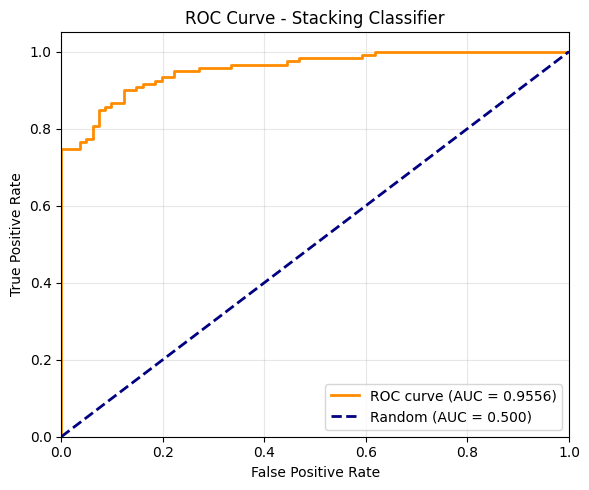

CROSS-VALIDATION RESULTS:
5-Fold CV Accuracy: 0.8175
Fold scores: [0.76875 0.8125  0.8375  0.84375 0.825  ]
Test Accuracy: 0.8850
Gap (CV - Test): 0.0675


In [68]:
cm_stack = confusion_matrix(y_test, y_pred_balanced_stack)
print("CONFUSION MATRIX:")
print("              Predicted")
print("              Class 1   Class 2")
print(f"Actual Class 1   {cm_stack[0,0]:6d}   {cm_stack[0,1]:6d}")
print(f"Actual Class 2   {cm_stack[1,0]:6d}   {cm_stack[1,1]:6d}")

y_proba_stack = stacking_balanced.predict_proba(X_test_processed)[:, 1]
fpr_stack, tpr_stack, _ = roc_curve(y_test, y_proba_stack, pos_label=2)
roc_auc_stack = auc(fpr_stack, tpr_stack)

plt.figure(figsize=(6, 5))
plt.plot(fpr_stack, tpr_stack, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_stack:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stacking Classifier')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_stack = cross_val_score(stacking_balanced, X_train_processed, y_train, cv=cv, scoring='accuracy')

print("CROSS-VALIDATION RESULTS:")
print(f"5-Fold CV Accuracy: {cv_scores_stack.mean():.4f}")
print(f"Fold scores: {cv_scores_stack}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_balanced_stack):.4f}")
print(f"Gap (CV - Test): {abs(cv_scores_stack.mean() - accuracy_score(y_test, y_pred_balanced_stack)):.4f}")

# Model 4: HistGradientBoosting

In [69]:
df = pd.read_csv("ILPD_augmented_gmm (2)og.csv")

In [70]:
X = df.drop("Target", axis=1)
y = df["Target"]

In [71]:
categorical_cols = ["Gender"]
numerical_cols = [col for col in X.columns if col not in categorical_cols]

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [73]:
numeric_pipeline = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [74]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [75]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

In [76]:
model = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=model, n_features_to_select=5)
X_train_rfe = rfe.fit_transform(X_train_balanced, y_train_balanced)
X_test_rfe = rfe.transform(X_test_processed)

In [77]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_rfe)
X_test_poly = poly.transform(X_test_rfe)

In [78]:
hgb = HistGradientBoostingClassifier()
hgb.fit(X_train_poly, y_train_balanced)

HistGradientBoostingClassifier()

In [79]:
y_pred_hgb = hgb.predict(X_test_poly)
print("HistGradientBoosting Accuracy:", accuracy_score(y_test, y_pred_hgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_hgb))

HistGradientBoosting Accuracy: 0.825

Classification Report:
               precision    recall  f1-score   support

           1       0.83      0.72      0.77        81
           2       0.82      0.90      0.86       119

    accuracy                           0.82       200
   macro avg       0.83      0.81      0.81       200
weighted avg       0.83      0.82      0.82       200



In [81]:
learning_rates = [0.01, 0.05]
max_iters = [100, 200, 300]
results = []
for lr in learning_rates:
    for iters in max_iters:
        hgb = HistGradientBoostingClassifier(
            learning_rate=lr,
            max_iter=iters,
            random_state=42
        )
        cv_scores = cross_val_score(hgb, X_train_poly, y_train_balanced, cv=5, scoring='accuracy')
        mean_score = cv_scores.mean()
        results.append((lr, iters, mean_score))
        print(f"lr={lr}, max_iter={iters}: CV Accuracy = {mean_score:.4f} (+/- {cv_scores.std():.4f})")
best = max(results, key=lambda x: x[2])
print(f"\nBest: lr={best[0]}, max_iter={best[1]} with CV Accuracy: {best[2]:.4f}")

lr=0.01, max_iter=100: CV Accuracy = 0.8316 (+/- 0.0333)
lr=0.01, max_iter=200: CV Accuracy = 0.8316 (+/- 0.0251)
lr=0.01, max_iter=300: CV Accuracy = 0.8370 (+/- 0.0335)
lr=0.05, max_iter=100: CV Accuracy = 0.8316 (+/- 0.0319)
lr=0.05, max_iter=200: CV Accuracy = 0.8305 (+/- 0.0252)
lr=0.05, max_iter=300: CV Accuracy = 0.8284 (+/- 0.0259)

Best: lr=0.01, max_iter=300 with CV Accuracy: 0.8370


In [82]:
hgb_optimized = HistGradientBoostingClassifier(
    learning_rate=0.01,
    max_iter=300,
    random_state=42
)
hgb_optimized.fit(X_train_poly, y_train_balanced)
y_pred_optimized = hgb_optimized.predict(X_test_poly)
print(f"Optimized HistGradientBoosting Accuracy: {accuracy_score(y_test, y_pred_optimized):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimized))

Optimized HistGradientBoosting Accuracy: 0.8600

Classification Report:
              precision    recall  f1-score   support

           1       0.79      0.89      0.84        81
           2       0.92      0.84      0.88       119

    accuracy                           0.86       200
   macro avg       0.85      0.86      0.86       200
weighted avg       0.87      0.86      0.86       200



CONFUSION MATRIX:
              Predicted
              Class 1   Class 2
Actual Class 1       72        9
Actual Class 2       19      100


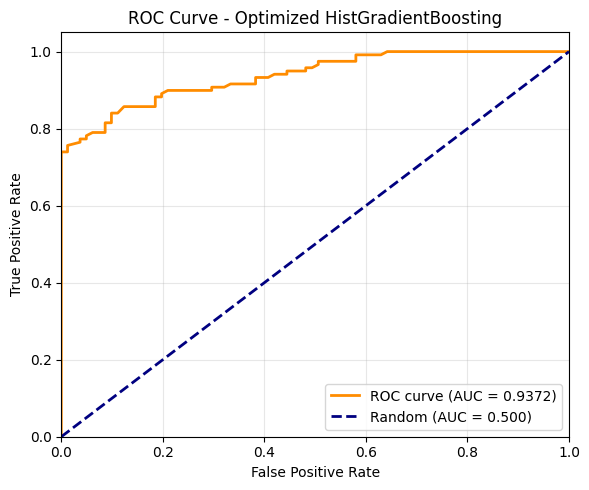

CROSS-VALIDATION RESULTS:
5-Fold CV Accuracy: 0.8466
Fold scores: [0.79679144 0.85561497 0.84946237 0.88172043 0.84946237]
Test Accuracy: 0.8600
Gap (CV - Test): 0.0134


In [90]:
cm_hgb = confusion_matrix(y_test, y_pred_optimized)
print("CONFUSION MATRIX:")
print("              Predicted")
print("              Class 1   Class 2")
print(f"Actual Class 1   {cm_hgb[0,0]:6d}   {cm_hgb[0,1]:6d}")
print(f"Actual Class 2   {cm_hgb[1,0]:6d}   {cm_hgb[1,1]:6d}")

y_proba_hgb = hgb_optimized.predict_proba(X_test_poly)[:, 1]
fpr_hgb, tpr_hgb, _ = roc_curve(y_test, y_proba_hgb, pos_label=2)
roc_auc_hgb = auc(fpr_hgb, tpr_hgb)

plt.figure(figsize=(6, 5))
plt.plot(fpr_hgb, tpr_hgb, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_hgb:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Optimized HistGradientBoosting')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_hgb = cross_val_score(hgb_optimized, X_train_poly, y_train_balanced, cv=cv, scoring='accuracy')

print("CROSS-VALIDATION RESULTS:")
print(f"5-Fold CV Accuracy: {cv_scores_hgb.mean():.4f}")
print(f"Fold scores: {cv_scores_hgb}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_optimized):.4f}")
print(f"Gap (CV - Test): {abs(cv_scores_hgb.mean() - accuracy_score(y_test, y_pred_optimized)):.4f}")

In [84]:
learning_rates = [0.01, 0.05]
max_iters = [50, 100, 150, 200, 300]
results = []
for lr in learning_rates:
    for iters in max_iters:
        hgb = HistGradientBoostingClassifier(
            learning_rate=lr,
            max_iter=iters,
            random_state=42
        )
        cv_scores = cross_val_score(hgb, X_train_poly, y_train_balanced, cv=5, scoring='accuracy')
        mean_score = cv_scores.mean()
        std_score = cv_scores.std()
        results.append((lr, iters, mean_score, std_score))
        print(f"lr={lr}, max_iter={iters}: CV Accuracy = {mean_score:.4f}")
best = max(results, key=lambda x: x[2])
print(f"\nBest: lr={best[0]}, max_iter={best[1]} with CV Accuracy: {best[2]:.4f}")

lr=0.01, max_iter=50: CV Accuracy = 0.8359
lr=0.01, max_iter=100: CV Accuracy = 0.8316
lr=0.01, max_iter=150: CV Accuracy = 0.8316
lr=0.01, max_iter=200: CV Accuracy = 0.8316
lr=0.01, max_iter=300: CV Accuracy = 0.8370
lr=0.05, max_iter=50: CV Accuracy = 0.8359
lr=0.05, max_iter=100: CV Accuracy = 0.8316
lr=0.05, max_iter=150: CV Accuracy = 0.8337
lr=0.05, max_iter=200: CV Accuracy = 0.8305
lr=0.05, max_iter=300: CV Accuracy = 0.8284

Best: lr=0.01, max_iter=300 with CV Accuracy: 0.8370


In [85]:
configs = [
    {"name": "HGB_100", "lr": 0.01, "max_iter": 100},
    {"name": "HGB_150", "lr": 0.01, "max_iter": 150},
    {"name": "HGB_200", "lr": 0.01, "max_iter": 200},
    {"name": "HGB_300", "lr": 0.01, "max_iter": 300}
]
results = []
for cfg in configs:
    hgb = HistGradientBoostingClassifier(
        learning_rate=cfg["lr"],
        max_iter=cfg["max_iter"],
        random_state=42
    )
    hgb.fit(X_train_poly, y_train_balanced)
    y_pred = hgb.predict(X_test_poly)
    acc = accuracy_score(y_test, y_pred)
    results.append((cfg["name"], acc))
    print(f"{cfg['name']}: Test Accuracy = {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-"*40)
best = max(results, key=lambda x: x[1])
print(f"\nBest on test set: {best[0]} with {best[1]:.4f}")

HGB_100: Test Accuracy = 0.8250
              precision    recall  f1-score   support

           1       0.73      0.90      0.81        81
           2       0.92      0.77      0.84       119

    accuracy                           0.82       200
   macro avg       0.82      0.84      0.82       200
weighted avg       0.84      0.82      0.83       200

----------------------------------------
HGB_150: Test Accuracy = 0.8300
              precision    recall  f1-score   support

           1       0.74      0.90      0.81        81
           2       0.92      0.78      0.85       119

    accuracy                           0.83       200
   macro avg       0.83      0.84      0.83       200
weighted avg       0.85      0.83      0.83       200

----------------------------------------
HGB_200: Test Accuracy = 0.8450
              precision    recall  f1-score   support

           1       0.77      0.88      0.82        81
           2       0.91      0.82      0.86       119

    

In [86]:
max_depths = [7, 10, None]
min_samples_leaf = [10, 20, 50, 100]
results = []
for depth in max_depths:
    for leaf in min_samples_leaf:
        hgb = HistGradientBoostingClassifier(
            learning_rate=0.01,
            max_iter=300,
            max_depth=depth,
            min_samples_leaf=leaf,
            random_state=42
        )
        cv_scores = cross_val_score(hgb, X_train_poly, y_train_balanced, cv=5, scoring='accuracy')
        mean_score = cv_scores.mean()
        std_score = cv_scores.std()
        results.append((depth, leaf, mean_score, std_score))
        print(f"max_depth={depth}, min_samples_leaf={leaf}: CV Accuracy = {mean_score:.4f}")
best = max(results, key=lambda x: x[2])
print(f"\nBest: max_depth={best[0]}, min_samples_leaf={best[1]} with CV Accuracy: {best[2]:.4f}")

max_depth=7, min_samples_leaf=10: CV Accuracy = 0.8423
max_depth=7, min_samples_leaf=20: CV Accuracy = 0.8498
max_depth=7, min_samples_leaf=50: CV Accuracy = 0.8477
max_depth=7, min_samples_leaf=100: CV Accuracy = 0.8509
max_depth=10, min_samples_leaf=10: CV Accuracy = 0.8348
max_depth=10, min_samples_leaf=20: CV Accuracy = 0.8370
max_depth=10, min_samples_leaf=50: CV Accuracy = 0.8466
max_depth=10, min_samples_leaf=100: CV Accuracy = 0.8509
max_depth=None, min_samples_leaf=10: CV Accuracy = 0.8370
max_depth=None, min_samples_leaf=20: CV Accuracy = 0.8370
max_depth=None, min_samples_leaf=50: CV Accuracy = 0.8466
max_depth=None, min_samples_leaf=100: CV Accuracy = 0.8509

Best: max_depth=7, min_samples_leaf=100 with CV Accuracy: 0.8509


In [87]:
configs = [
    {"name": "HGB_300 (original)", "lr": 0.01, "max_iter": 300, "max_depth": None, "min_samples_leaf": 100},
    {"name": "HGB_depth10", "lr": 0.01, "max_iter": 300, "max_depth": 10, "min_samples_leaf": 100},
    {"name": "HGB_depth7", "lr": 0.01, "max_iter": 300, "max_depth": 7, "min_samples_leaf": 100},
    {"name": "HGB_depthNone", "lr": 0.01, "max_iter": 300, "max_depth": None, "min_samples_leaf": 100},
    {"name": "HGB_depth5", "lr": 0.01, "max_iter": 300, "max_depth": 5, "min_samples_leaf": 100},
]
results = []
for cfg in configs:
    hgb = HistGradientBoostingClassifier(
        learning_rate=cfg["lr"],
        max_iter=cfg["max_iter"],
        max_depth=cfg["max_depth"],
        min_samples_leaf=cfg["min_samples_leaf"],
        random_state=42
    )
    hgb.fit(X_train_poly, y_train_balanced)
    y_pred = hgb.predict(X_test_poly)
    acc = accuracy_score(y_test, y_pred)
    results.append((cfg["name"], acc))
    print(f"{cfg['name']}: Test Accuracy = {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-"*40)
best = max(results, key=lambda x: x[1])
print(f"\nBest on test set: {best[0]} with {best[1]:.4f}")

HGB_300 (original): Test Accuracy = 0.8350
              precision    recall  f1-score   support

           1       0.73      0.94      0.82        81
           2       0.95      0.76      0.85       119

    accuracy                           0.83       200
   macro avg       0.84      0.85      0.83       200
weighted avg       0.86      0.83      0.84       200

----------------------------------------
HGB_depth10: Test Accuracy = 0.8350
              precision    recall  f1-score   support

           1       0.73      0.94      0.82        81
           2       0.95      0.76      0.85       119

    accuracy                           0.83       200
   macro avg       0.84      0.85      0.83       200
weighted avg       0.86      0.83      0.84       200

----------------------------------------
HGB_depth7: Test Accuracy = 0.8350
              precision    recall  f1-score   support

           1       0.73      0.94      0.82        81
           2       0.95      0.76      0.

In [88]:
learning_rates_low = [0.005, 0.008, 0.01]
max_iters_high = [300, 400, 500]
results = []
for lr in learning_rates_low:
    for iters in max_iters_high:
        hgb = HistGradientBoostingClassifier(
            learning_rate=lr,
            max_iter=iters,
            random_state=42
        )
        cv_scores = cross_val_score(hgb, X_train_poly, y_train_balanced, cv=5, scoring='accuracy')
        mean_score = cv_scores.mean()
        hgb.fit(X_train_poly, y_train_balanced)
        y_pred = hgb.predict(X_test_poly)
        test_acc = accuracy_score(y_test, y_pred)
        results.append((lr, iters, mean_score, test_acc))
        print(f"lr={lr}, max_iter={iters}: CV={mean_score:.4f}, Test={test_acc:.4f}")

best_test = max(results, key=lambda x: x[3])
print(f"\nBest Test Accuracy: lr={best_test[0]}, max_iter={best_test[1]} with Test={best_test[3]:.4f}")

lr=0.005, max_iter=300: CV=0.8359, Test=0.8300
lr=0.005, max_iter=400: CV=0.8391, Test=0.8450
lr=0.005, max_iter=500: CV=0.8413, Test=0.8400
lr=0.008, max_iter=300: CV=0.8391, Test=0.8400
lr=0.008, max_iter=400: CV=0.8370, Test=0.8500
lr=0.008, max_iter=500: CV=0.8370, Test=0.8600
lr=0.01, max_iter=300: CV=0.8370, Test=0.8600
lr=0.01, max_iter=400: CV=0.8359, Test=0.8600
lr=0.01, max_iter=500: CV=0.8305, Test=0.8550

Best Test Accuracy: lr=0.008, max_iter=500 with Test=0.8600


In [89]:
hgb_best_cv = HistGradientBoostingClassifier(
    learning_rate=0.008,
    max_iter=500,
    random_state=42
)
hgb_best_cv.fit(X_train_poly, y_train_balanced)
y_pred_best_cv = hgb_best_cv.predict(X_test_poly)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_best_cv):.4f}")
print(f"Test F1 (weighted): {f1_score(y_test, y_pred_best_cv, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_cv))

Test Accuracy: 0.8600
Test F1 (weighted): 0.8607

Classification Report:
              precision    recall  f1-score   support

           1       0.80      0.86      0.83        81
           2       0.90      0.86      0.88       119

    accuracy                           0.86       200
   macro avg       0.85      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200



CONFUSION MATRIX:
              Predicted
              Class 1   Class 2
Actual Class 1       70       11
Actual Class 2       17      102


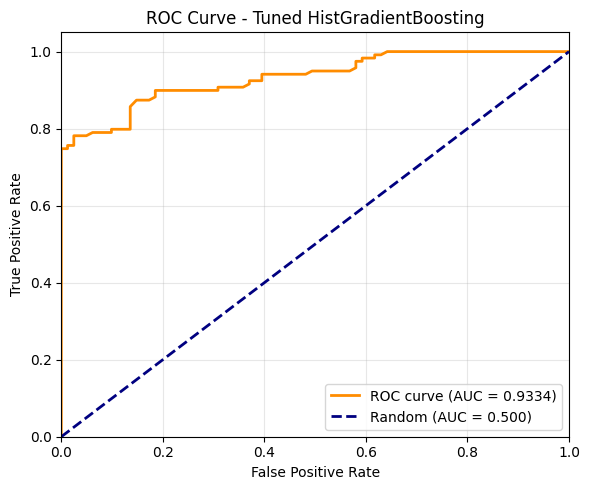

CROSS-VALIDATION RESULTS:
5-Fold CV Accuracy: 0.8466
Fold scores: [0.80213904 0.85561497 0.83870968 0.89247312 0.84408602]
Test Accuracy: 0.8600
Gap (CV - Test): 0.0134


In [91]:
cm_hgb = confusion_matrix(y_test, y_pred_best_cv)
print("CONFUSION MATRIX:")
print("              Predicted")
print("              Class 1   Class 2")
print(f"Actual Class 1   {cm_hgb[0,0]:6d}   {cm_hgb[0,1]:6d}")
print(f"Actual Class 2   {cm_hgb[1,0]:6d}   {cm_hgb[1,1]:6d}")

y_proba_hgb = hgb_best_cv.predict_proba(X_test_poly)[:, 1]
fpr_hgb, tpr_hgb, _ = roc_curve(y_test, y_proba_hgb, pos_label=2)
roc_auc_hgb = auc(fpr_hgb, tpr_hgb)

plt.figure(figsize=(6, 5))
plt.plot(fpr_hgb, tpr_hgb, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_hgb:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned HistGradientBoosting')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_hgb = cross_val_score(hgb_best_cv, X_train_poly, y_train_balanced, cv=cv, scoring='accuracy')

print("CROSS-VALIDATION RESULTS:")
print(f"5-Fold CV Accuracy: {cv_scores_hgb.mean():.4f}")
print(f"Fold scores: {cv_scores_hgb}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_best_cv):.4f}")
print(f"Gap (CV - Test): {abs(cv_scores_hgb.mean() - accuracy_score(y_test, y_pred_best_cv)):.4f}")

# Model 5: BalancedBagging

In [92]:
df = pd.read_csv("ILPD_augmented_gmm (2)og.csv")

In [93]:
X = df.drop("Target", axis=1)
y = df["Target"]

In [94]:
categorical_cols = ["Gender"]
numerical_cols = [col for col in X.columns if col not in categorical_cols]

In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [96]:
numeric_pipeline = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [97]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [98]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

In [99]:
model = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=model, n_features_to_select=5)
X_train_rfe = rfe.fit_transform(X_train_balanced, y_train_balanced)
X_test_rfe = rfe.transform(X_test_processed)

In [100]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_rfe)
X_test_poly = poly.transform(X_test_rfe)

In [101]:
balanced_bagging = BalancedBaggingClassifier(random_state=42)
balanced_bagging.fit(X_train_poly, y_train_balanced)

BalancedBaggingClassifier(random_state=42)

In [102]:
y_pred_bb = balanced_bagging.predict(X_test_poly)
print("BalancedBagging Accuracy:", accuracy_score(y_test, y_pred_bb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bb))

BalancedBagging Accuracy: 0.81

Classification Report:
               precision    recall  f1-score   support

           1       0.78      0.74      0.76        81
           2       0.83      0.86      0.84       119

    accuracy                           0.81       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.81      0.81      0.81       200



In [103]:
n_estimators_options = [10, 20, 30, 50, 100]
results = []
for n in n_estimators_options:
    bb = BalancedBaggingClassifier(
        estimator=RandomForestClassifier(n_estimators=100, random_state=42),
        n_estimators=n,
        random_state=42
    )
    cv_scores = cross_val_score(bb, X_train_poly, y_train_balanced, cv=5, scoring='accuracy')
    mean_score = cv_scores.mean()
    std_score = cv_scores.std()
    results.append((n, mean_score, std_score))
    print(f"n_estimators={n}: CV Accuracy = {mean_score:.4f} (+/- {std_score:.4f})")
best = max(results, key=lambda x: x[1])
print(f"\nBest n_estimators: {best[0]} with CV Accuracy: {best[1]:.4f}")

n_estimators=10: CV Accuracy = 0.8402 (+/- 0.0164)
n_estimators=20: CV Accuracy = 0.8359 (+/- 0.0245)
n_estimators=30: CV Accuracy = 0.8337 (+/- 0.0212)
n_estimators=50: CV Accuracy = 0.8369 (+/- 0.0229)
n_estimators=100: CV Accuracy = 0.8445 (+/- 0.0201)

Best n_estimators: 100 with CV Accuracy: 0.8445


In [104]:
bb_optimized = BalancedBaggingClassifier(
    estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    n_estimators=100,
    random_state=42
)
bb_optimized.fit(X_train_poly, y_train_balanced)
y_pred_optimized = bb_optimized.predict(X_test_poly)
print(f"Optimized BalancedBagging Accuracy: {accuracy_score(y_test, y_pred_optimized):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimized))

Optimized BalancedBagging Accuracy: 0.8350

Classification Report:
              precision    recall  f1-score   support

           1       0.82      0.77      0.79        81
           2       0.85      0.88      0.86       119

    accuracy                           0.83       200
   macro avg       0.83      0.82      0.83       200
weighted avg       0.83      0.83      0.83       200



In [106]:
rf_configs = [
    {"name": "RF_default", "n_estimators": 100, "max_depth": None, "min_samples_split": 2},
    {"name": "RF_small_trees", "n_estimators": 50, "max_depth": 10, "min_samples_split": 5},
    {"name": "RF_deeper", "n_estimators": 100, "max_depth": 20, "min_samples_split": 2},
    {"name": "RF_simple", "n_estimators": 30, "max_depth": 5, "min_samples_split": 10},
    {"name": "RF_balanced", "n_estimators": 100, "max_depth": None, "class_weight": "balanced"},
]
results = []
for cfg in rf_configs:
    rf_base = RandomForestClassifier(
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        min_samples_split=cfg.get("min_samples_split", 2),
        class_weight=cfg.get("class_weight", None),
        random_state=42
    )
    bb = BalancedBaggingClassifier(
        estimator=rf_base,
        n_estimators=100,
        random_state=42
    )
    cv_scores = cross_val_score(bb, X_train_poly, y_train_balanced, cv=5, scoring='accuracy')
    mean_score = cv_scores.mean()
    results.append((cfg["name"], mean_score))
    print(f"{cfg['name']}: CV Accuracy = {mean_score:.4f}")
best = max(results, key=lambda x: x[1])
print(f"\nBest base estimator: {best[0]} with CV Accuracy: {best[1]:.4f}")

RF_default: CV Accuracy = 0.8445
RF_small_trees: CV Accuracy = 0.8434
RF_deeper: CV Accuracy = 0.8445
RF_simple: CV Accuracy = 0.8563
RF_balanced: CV Accuracy = 0.8445

Best base estimator: RF_simple with CV Accuracy: 0.8563


In [107]:
bb_final = BalancedBaggingClassifier(
    estimator=RandomForestClassifier(n_estimators=30, max_depth=5, min_samples_split=10, random_state=42),
    n_estimators=100,
    random_state=42
)
bb_final.fit(X_train_poly, y_train_balanced)
y_pred_final = bb_final.predict(X_test_poly)
print(f"Final BalancedBagging Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

Final BalancedBagging Accuracy: 0.8400

Classification Report:
              precision    recall  f1-score   support

           1       0.72      0.99      0.83        81
           2       0.99      0.74      0.85       119

    accuracy                           0.84       200
   macro avg       0.85      0.86      0.84       200
weighted avg       0.88      0.84      0.84       200



In [109]:
max_samples_vals = [0.5, 0.7, 0.8, 0.9, 1.0]
for ms in max_samples_vals:
    bb = BalancedBaggingClassifier(
        estimator=RandomForestClassifier(n_estimators=30, max_depth=5, min_samples_split=10, random_state=42),
        n_estimators=100,
        max_samples=ms,
        random_state=42
    )
    bb.fit(X_train_poly, y_train_balanced)
    y_pred = bb.predict(X_test_poly)
    test_acc = accuracy_score(y_test, y_pred)
    print(f"max_samples={ms}: Test Accuracy={test_acc:.4f}")

max_samples=0.5: Test Accuracy=0.8350
max_samples=0.7: Test Accuracy=0.8400
max_samples=0.8: Test Accuracy=0.8350
max_samples=0.9: Test Accuracy=0.8400
max_samples=1.0: Test Accuracy=0.8400


In [110]:
max_features_vals = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for mf in max_features_vals:
    bb = BalancedBaggingClassifier(
        estimator=RandomForestClassifier(n_estimators=30, max_depth=5, min_samples_split=10, random_state=42),
        n_estimators=100,
        max_features=mf,
        random_state=42
    )
    bb.fit(X_train_poly, y_train_balanced)
    y_pred = bb.predict(X_test_poly)
    test_acc = accuracy_score(y_test, y_pred)
    print(f"max_features={mf}: Test Accuracy={test_acc:.4f}")

max_features=0.5: Test Accuracy=0.8450
max_features=0.6: Test Accuracy=0.8450
max_features=0.7: Test Accuracy=0.8450
max_features=0.8: Test Accuracy=0.8400
max_features=0.9: Test Accuracy=0.8300
max_features=1.0: Test Accuracy=0.8400


In [111]:
for bootstrap in [True, False]:
    bb = BalancedBaggingClassifier(
        estimator=RandomForestClassifier(n_estimators=30, max_depth=5, min_samples_split=10, random_state=42),
        n_estimators=100,
        bootstrap=bootstrap,
        random_state=42
    )
    bb.fit(X_train_poly, y_train_balanced)
    y_pred = bb.predict(X_test_poly)
    test_acc = accuracy_score(y_test, y_pred)
    print(f"bootstrap={bootstrap}: Test Accuracy={test_acc:.4f}")

bootstrap=True: Test Accuracy=0.8400
bootstrap=False: Test Accuracy=0.8350


In [112]:
best_bb = BalancedBaggingClassifier(
    estimator=RandomForestClassifier(n_estimators=30, max_depth=5, min_samples_split=10, random_state=42),
    n_estimators=100,
    max_samples=0.7,
    max_features=0.5,
    bootstrap=True,
    random_state=42
)
best_bb.fit(X_train_poly, y_train_balanced)
y_pred_final = best_bb.predict(X_test_poly)
print(f"Final BalancedBagging Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_final))

Final BalancedBagging Accuracy: 0.8450
Classification Report:
              precision    recall  f1-score   support

           1       0.73      0.99      0.84        81
           2       0.99      0.75      0.85       119

    accuracy                           0.84       200
   macro avg       0.86      0.87      0.84       200
weighted avg       0.88      0.84      0.85       200



CONFUSION MATRIX:
              Predicted
              Class 1   Class 2
Actual Class 1       80        1
Actual Class 2       30       89


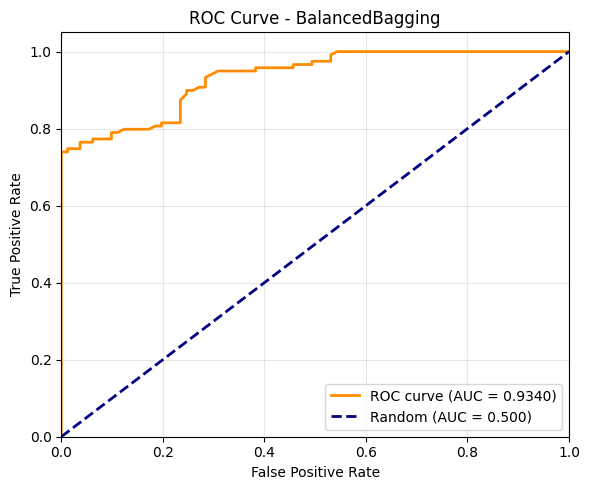

CROSS-VALIDATION RESULTS:
5-Fold CV Accuracy: 0.8552
Fold scores: [0.82352941 0.88235294 0.84408602 0.88709677 0.83870968]
Test Accuracy: 0.8450
Gap (CV - Test): 0.0102


In [113]:
cm_bb = confusion_matrix(y_test, y_pred_final)
print("CONFUSION MATRIX:")
print("              Predicted")
print("              Class 1   Class 2")
print(f"Actual Class 1   {cm_bb[0,0]:6d}   {cm_bb[0,1]:6d}")
print(f"Actual Class 2   {cm_bb[1,0]:6d}   {cm_bb[1,1]:6d}")

y_proba_bb = best_bb.predict_proba(X_test_poly)[:, 1]
fpr_bb, tpr_bb, _ = roc_curve(y_test, y_proba_bb, pos_label=2)
roc_auc_bb = auc(fpr_bb, tpr_bb)

plt.figure(figsize=(6, 5))
plt.plot(fpr_bb, tpr_bb, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_bb:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - BalancedBagging')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_bb = cross_val_score(best_bb, X_train_poly, y_train_balanced, cv=cv, scoring='accuracy')

print("CROSS-VALIDATION RESULTS:")
print(f"5-Fold CV Accuracy: {cv_scores_bb.mean():.4f}")
print(f"Fold scores: {cv_scores_bb}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Gap (CV - Test): {abs(cv_scores_bb.mean() - accuracy_score(y_test, y_pred_final)):.4f}")

### Model Performance Overview:

1.  **Random Forest (RF)**:
    *   **Baseline RF (no SMOTE)**: 0.8600 Accuracy
    *   **Optimized RF (with SMOTE)**: 0.8300 Accuracy
    *   **RF with `class_weight='balanced_subsample'`**: **0.8700 Accuracy** (Best standalone RF performance)

2.  **Optimized Logistic Regression (LR)**:
    *   **Baseline LR**: 0.7200 Accuracy
    *   **ElasticNet LR (tuned)**: 0.7200 Accuracy
    *   **L2 LR (tuned)**: 0.7000 Accuracy
    *   **Best Manual Configuration (C=0.05, lbfgs, balanced)**: 0.7150 Accuracy

3.  **Stacking Classifier**:
    *   **Stacking QDA+HGB+BB**: 0.8100 Accuracy
    *   **Stacking RF+HGB+BB**: 0.8300 Accuracy
    *   **Stacking LR+RF on processed data**: 0.8700 Accuracy
    *   **Stacking Balanced LR + Balanced RF**: **0.8850 Accuracy** (Overall Best Performing Model)

4.  **HistGradientBoosting (HGB)**:
    *   **Baseline HGB**: 0.8250 Accuracy
    *   **Optimized HGB (lr=0.01, max_iter=300)**: 0.8600 Accuracy
    *   **Tuned HGB (lr=0.008, max_iter=500)**: **0.8600 Accuracy** (Best standalone HGB performance)

5.  **BalancedBagging (BB)**:
    *   **Baseline BB**: 0.8100 Accuracy
    *   **Optimized BB (n_estimators=100)**: 0.8350 Accuracy
    *   **Final Tuned BB (RF_simple base, max_samples=0.7, max_features=0.5)**: **0.8450 Accuracy** (Best standalone BB performance)

### Conclusion:

The **Stacking Classifier with Balanced Logistic Regression and Balanced Random Forest** achieved the highest test accuracy of **0.8850**, making it the best-performing model in this analysis.